# 01. Load Raw BBC Dataset


In [20]:
from pathlib import Path
import pandas as pd

data_dir = Path("/Users/luongnhatkhoi/Desktop/ML_Projects/BBC_Classification/data")

rows = []

for label_dir in data_dir.iterdir():
    if label_dir.is_dir():
        label = label_dir.name

        for file_path in label_dir.glob("*.txt"):
            text = file_path.read_text(encoding="latin-1")
            rows.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(rows)

print(df.head())
print(df["label"].value_counts())

                                                text          label
0  Musicians to tackle US red tape\n\nMusicians' ...  entertainment
1  U2's desire to be number one\n\nU2, who have w...  entertainment
2  Rocker Doherty in on-stage fight\n\nRock singe...  entertainment
3  Snicket tops US box office chart\n\nThe film a...  entertainment
4  Ocean's Twelve raids box office\n\nOcean's Twe...  entertainment
label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


# 02. Clean and Validate Text Data


In [21]:
df = df.dropna(subset=["text", "label"])

df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0]

print(df.shape)

(2225, 2)


# 03. Encode Category Labels


In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label_id"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
print(df[["label", "label_id"]].head())

['business' 'entertainment' 'politics' 'sport' 'tech']
           label  label_id
0  entertainment         1
1  entertainment         1
2  entertainment         1
3  entertainment         1
4  entertainment         1


# 04. Stratified Train/Validation/Test Split


In [23]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_id"]
)

print(len(train_df), len(val_df), len(test_df))

1780 222 223


# 05. Initialize BERT Tokenizer


In [24]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 06. Sanity Check Tokenization


In [25]:
sample_text = train_df.iloc[0]["text"]

encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

print(encoding.keys())
print(encoding["input_ids"].shape)
print(encoding["attention_mask"].shape)
print(encoding["token_type_ids"].shape)

KeysView({'input_ids': tensor([[  101, 18550,  2708,  3138,  9602,  5217,  1996,  2708,  3237,  1997,
          1996, 18550, 22453,  2038,  2579,  2154,  1011,  2000,  1011,  2154,
          2491,  1997,  2049,  8084,  2482,  2449,  1999,  2019,  3947,  2000,
          2735,  2009,  2105,  1012, 13983,  2233,  3258,  2638,  2038,  2999,
          7253, 17183,  2884,  2004,  2708,  3237,  1997, 18550,  8285,  1010,
          2007,  2720, 17183,  2884,  2975,  1996,  2194,  1012,  2720,  2233,
          3258,  2638,  4150,  1996,  2959,  2132,  1997,  1996,  2449,  1011,
          2029,  2003,  3517,  2000,  2191,  1037,  5385,  2213,  9944,  1006,
          1002, 26314,  2078,  1007,  3279,  1999,  2432,  1011,  1999,  2004,
          2116,  2086,  1012, 18550,  2104,  4842, 29021,  1996,  3006,  1999,
          2885,  2197,  2095,  1010,  3773,  4257,  4341,  1012,  1996,  2482,
          2449,  2038,  2081,  2019,  4082,  3279,  1999,  2274,  1997,  1996,
          2197,  2416,  2086,

In [26]:
input_ids = encoding["input_ids"]
attention_mask = encoding["attention_mask"]
token_type_ids = encoding["token_type_ids"]

# 07. Build PyTorch Dataset Class


In [27]:
import torch
from torch.utils.data import Dataset

class BBCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "token_type_ids": encoding["token_type_ids"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# 08. Create Train/Validation/Test Dataset Objects


In [28]:
train_dataset = BBCDataset(
    train_df["text"],
    train_df["label_id"],
    tokenizer,
    max_length=256
)

val_dataset = BBCDataset(
    val_df["text"],
    val_df["label_id"],
    tokenizer,
    max_length=256
)

test_dataset = BBCDataset(
    test_df["text"],
    test_df["label_id"],
    tokenizer,
    max_length=256
)

# 09. Build DataLoaders


In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# 10. Verify Batch Shapes


In [30]:
batch = next(iter(train_loader))

print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("token_type_ids:", batch["token_type_ids"].shape)
print("labels:", batch["labels"].shape)

input_ids: torch.Size([16, 256])
attention_mask: torch.Size([16, 256])
token_type_ids: torch.Size([16, 256])
labels: torch.Size([16])


# 11. Import Training Utilities


In [31]:
import torch
from torch.optim import AdamW
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup

# 12. Select Training Device


In [32]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


# 13. Load BERT Sequence Classification Model


In [33]:
label2id = {
    label: int(idx)
    for idx, label in enumerate(label_encoder.classes_)
}
id2label = {
    int(idx): label
    for label, idx in label2id.items()
}

num_labels = len(label_encoder.classes_)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7970.54it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

# 14. Configure Optimizer


In [34]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

# 15. Configure Epochs and Learning Rate Scheduler


In [35]:
epochs = 3

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# 16. Define Evaluation Function


In [36]:
def evaluate(model, data_loader, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, f1

# 17. Initialize Training History


In [37]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": []
}

# 18. Fine-Tune BERT


In [38]:
for epoch in range(epochs):
    model.train()

    total_train_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs}"
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({
            "train_loss": loss.item()
        })

    avg_train_loss = total_train_loss / len(train_loader)

    val_loss, val_acc, val_f1 = evaluate(
        model,
        val_loader,
        device
    )

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"\nEpoch {epoch + 1}/{epochs}")
    print(f"Train loss: {avg_train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Val accuracy: {val_acc:.4f}")
    print(f"Val F1 macro: {val_f1:.4f}")

Epoch 1/3: 100%|██████████| 112/112 [01:36<00:00,  1.16it/s, train_loss=0.058] 



Epoch 1/3
Train loss: 0.6466
Val loss: 0.1192
Val accuracy: 0.9685
Val F1 macro: 0.9694


Epoch 2/3: 100%|██████████| 112/112 [01:35<00:00,  1.17it/s, train_loss=0.0143]



Epoch 2/3
Train loss: 0.0644
Val loss: 0.0732
Val accuracy: 0.9730
Val F1 macro: 0.9728


Epoch 3/3: 100%|██████████| 112/112 [01:34<00:00,  1.18it/s, train_loss=0.0103] 



Epoch 3/3
Train loss: 0.0275
Val loss: 0.0931
Val accuracy: 0.9775
Val F1 macro: 0.9772


# 19. Evaluate on Test Set


In [39]:
test_loss, test_acc, test_f1 = evaluate(
    model,
    test_loader,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1 macro: {test_f1:.4f}")

Test loss: 0.0461
Test accuracy: 0.9865
Test F1 macro: 0.9868


# 20. Generate Classification Report


In [40]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

               precision    recall  f1-score   support

     business       1.00      0.94      0.97        51
entertainment       1.00      1.00      1.00        39
     politics       0.95      1.00      0.98        42
        sport       1.00      1.00      1.00        51
         tech       0.98      1.00      0.99        40

     accuracy                           0.99       223
    macro avg       0.99      0.99      0.99       223
 weighted avg       0.99      0.99      0.99       223



# 21. Save Fine-Tuned Model and Tokenizer


In [41]:
model.save_pretrained("../models/bert_bbc")
tokenizer.save_pretrained("../models/bert_bbc")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]


('../models/bert_bbc/tokenizer_config.json',
 '../models/bert_bbc/tokenizer.json')

# 22. Save Label Mapping


In [42]:
import json

label_mapping = {
    label: int(idx)
    for idx, label in enumerate(label_encoder.classes_)
}

with open("../models/bert_bbc/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

print("Model saved to ../models/bert_bbc")

Model saved to ../models/bert_bbc


# 23. Plot Training and Validation Loss


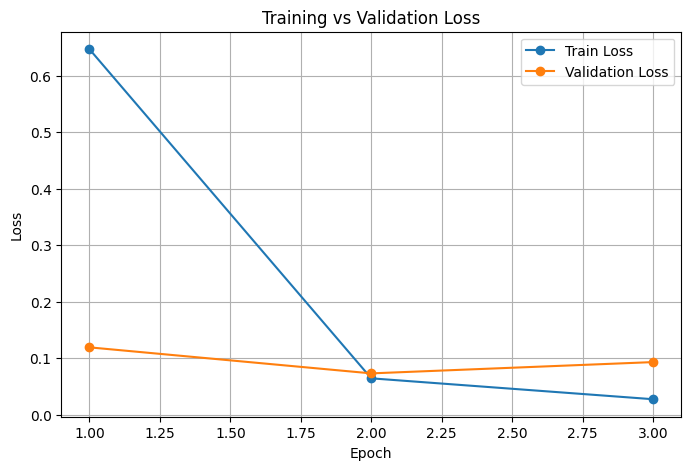

In [43]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 24. Plot Validation Accuracy and F1


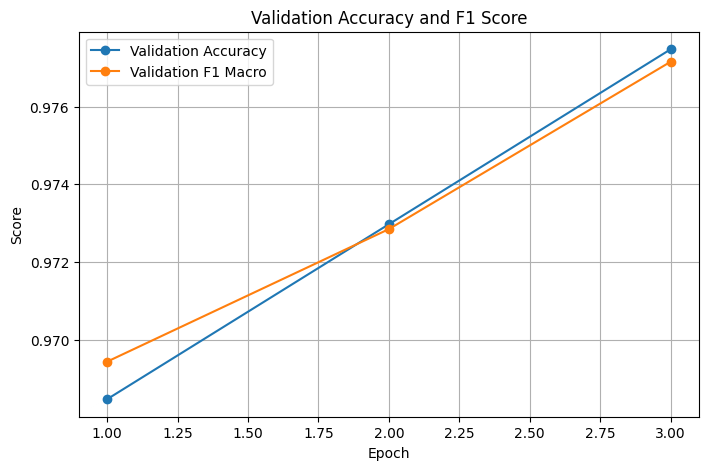

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    epochs_range,
    history["val_f1"],
    marker="o",
    label="Validation F1 Macro"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy and F1 Score")
plt.legend()
plt.grid(True)
plt.show()

# 25. Plot Test Confusion Matrix


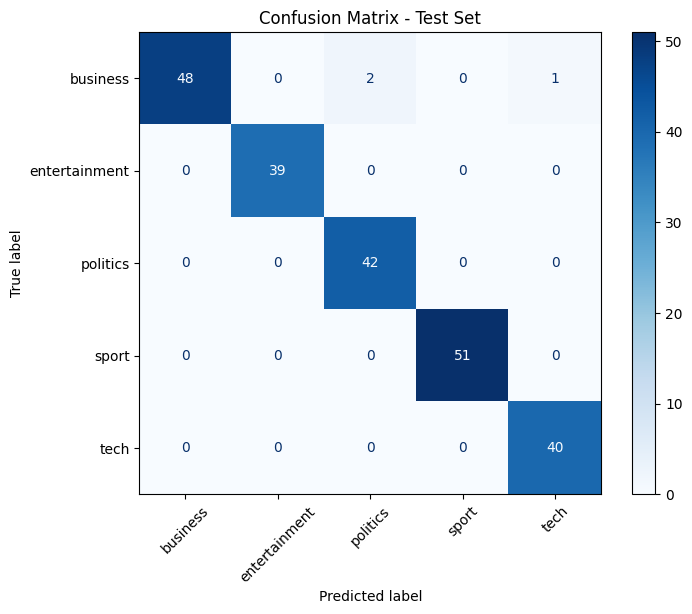

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Test Set")
plt.show()

# 26. Configure Stratified K-Fold Cross-Validation


In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support
import gc
import json
from pathlib import Path

CV_N_SPLITS = 5
CV_RANDOM_STATE = 42
CV_EPOCHS = epochs
CV_BATCH_SIZE = 16
CV_MAX_LENGTH = 256
CV_OUTPUT_DIR = Path("../models/bert_bbc_cv")
CV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cv_labels = df["label_id"].values
cv_splitter = StratifiedKFold(
    n_splits=CV_N_SPLITS,
    shuffle=True,
    random_state=CV_RANDOM_STATE
)

label2id = {
    label: int(idx)
    for idx, label in enumerate(label_encoder.classes_)
}
id2label = {
    int(idx): label
    for label, idx in label2id.items()
}

fold_sizes = []
for fold_idx, (_, val_idx) in enumerate(cv_splitter.split(df["text"], cv_labels), start=1):
    fold_distribution = (
        df.iloc[val_idx]["label"]
        .value_counts()
        .reindex(label_encoder.classes_)
        .to_dict()
    )
    fold_sizes.append({
        "fold": fold_idx,
        "validation_size": len(val_idx),
        **fold_distribution
    })

fold_distribution_df = pd.DataFrame(fold_sizes)
fold_distribution_df


,fold,validation_size,business,entertainment,politics,sport,tech
0,1,445,102,78,83,102,80
1,2,445,102,77,83,103,80
2,3,445,102,77,84,102,80
3,4,445,102,77,84,102,80
4,5,445,102,77,83,102,81


# 27. Define Cross-Validation Helper Functions


In [47]:
def build_bert_cv_model():
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=len(label_encoder.classes_),
        id2label=id2label,
        label2id=label2id
    )
    return model.to(device)


def compute_classification_metrics(labels, preds):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }


def evaluate_with_predictions(model, data_loader, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    metrics = compute_classification_metrics(all_labels, all_preds)
    metrics["val_loss"] = avg_loss

    return metrics, all_preds, all_labels


def save_fold_checkpoint(model, tokenizer, fold_dir, fold_metrics):
    fold_dir.mkdir(parents=True, exist_ok=True)

    model.save_pretrained(fold_dir)
    tokenizer.save_pretrained(fold_dir)

    with open(fold_dir / "label_mapping.json", "w") as f:
        json.dump(label2id, f, indent=4)

    with open(fold_dir / "fold_metrics.json", "w") as f:
        json.dump(fold_metrics, f, indent=4)


def clear_training_memory(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# 28. Run 5-Fold BERT Fine-Tuning


In [48]:
def train_one_cv_fold(fold_idx, train_idx, val_idx):
    fold_train_df = df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = df.iloc[val_idx].reset_index(drop=True)

    fold_train_dataset = BBCDataset(
        fold_train_df["text"],
        fold_train_df["label_id"],
        tokenizer,
        max_length=CV_MAX_LENGTH
    )
    fold_val_dataset = BBCDataset(
        fold_val_df["text"],
        fold_val_df["label_id"],
        tokenizer,
        max_length=CV_MAX_LENGTH
    )

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=CV_BATCH_SIZE,
        shuffle=True
    )
    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_size=CV_BATCH_SIZE,
        shuffle=False
    )

    fold_model = build_bert_cv_model()
    fold_optimizer = AdamW(
        fold_model.parameters(),
        lr=3e-5
    )
    fold_total_steps = len(fold_train_loader) * CV_EPOCHS
    fold_scheduler = get_linear_schedule_with_warmup(
        fold_optimizer,
        num_warmup_steps=0,
        num_training_steps=fold_total_steps
    )

    best_metrics = None
    best_preds = None
    best_labels = None
    best_f1 = -1
    fold_history = []
    fold_dir = CV_OUTPUT_DIR / f"fold_{fold_idx}_best"

    for epoch in range(CV_EPOCHS):
        fold_model.train()
        total_train_loss = 0

        progress_bar = tqdm(
            fold_train_loader,
            desc=f"Fold {fold_idx}/{CV_N_SPLITS} - Epoch {epoch + 1}/{CV_EPOCHS}"
        )

        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)

            fold_optimizer.zero_grad()

            outputs = fold_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                fold_model.parameters(),
                max_norm=1.0
            )

            fold_optimizer.step()
            fold_scheduler.step()

            progress_bar.set_postfix({
                "train_loss": loss.item()
            })

        avg_train_loss = total_train_loss / len(fold_train_loader)
        val_metrics, val_preds, val_labels = evaluate_with_predictions(
            fold_model,
            fold_val_loader,
            device
        )

        epoch_metrics = {
            "fold": fold_idx,
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            **val_metrics
        }
        fold_history.append(epoch_metrics)

        print(
            f"Fold {fold_idx} | Epoch {epoch + 1}/{CV_EPOCHS} | "
            f"Train loss: {avg_train_loss:.4f} | "
            f"Val loss: {val_metrics['val_loss']:.4f} | "
            f"Val accuracy: {val_metrics['accuracy']:.4f} | "
            f"Val F1 macro: {val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            best_metrics = epoch_metrics.copy()
            best_preds = val_preds.copy()
            best_labels = val_labels.copy()
            save_fold_checkpoint(
                fold_model,
                tokenizer,
                fold_dir,
                best_metrics
            )

    clear_training_memory(fold_model)

    return {
        "fold": fold_idx,
        "best_metrics": best_metrics,
        "history": fold_history,
        "preds": best_preds,
        "labels": best_labels,
        "checkpoint_dir": str(fold_dir)
    }


In [49]:
cv_fold_results = []
all_oof_preds = []
all_oof_labels = []

for fold_idx, (train_idx, val_idx) in enumerate(
    cv_splitter.split(df["text"], cv_labels),
    start=1
):
    print(f"\n========== Fold {fold_idx}/{CV_N_SPLITS} ==========")
    fold_result = train_one_cv_fold(
        fold_idx,
        train_idx,
        val_idx
    )
    cv_fold_results.append(fold_result)
    all_oof_preds.extend(fold_result["preds"])
    all_oof_labels.extend(fold_result["labels"])

print("Cross-validation finished.")



========== Fold 1/5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8730.00it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Fold 1 | Epoch 1/3 | Train loss: 0.4809 | Val loss: 0.0895 | Val accuracy: 0.9775 | Val F1 macro: 0.9767


Fold 1/5 - Epoch 2/3: 100%|██████████| 112/112 [01:35<00:00,  1.18it/s, train_loss=0.00808]


Fold 1 | Epoch 2/3 | Train loss: 0.0488 | Val loss: 0.0677 | Val accuracy: 0.9865 | Val F1 macro: 0.9865


...

Fold 2 | Epoch 1/3 | Train loss: 0.4419 | Val loss: 0.1295 | Val accuracy: 0.9663 | Val F1 macro: 0.9662


Fold 2/5 - Epoch 2/3: 100%|██████████| 112/112 [01:35<00:00,  1.18it/s, train_loss=0.00848]


Fold 2 | Epoch 2/3 | Train loss: 0.0589 | Val loss: 0.0979 | Val accuracy: 0.9753 | Val F1 macro: 0.9748


Fold 2/5 - Epoch 3/3:  54%|█████▍    | 61/112 [00:53<00:44,  1.14it/s, train_loss=0.00584]


KeyboardInterrupt: 

# 29. Summarize Cross-Validation Metrics


In [ ]:
cv_results_df = pd.DataFrame([
    {
        **result["best_metrics"],
        "checkpoint_dir": result["checkpoint_dir"]
    }
    for result in cv_fold_results
])

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]

cv_summary_df = cv_results_df[metric_columns].agg(["mean", "std"])

print("Best metrics per fold:")
display(cv_results_df)

print("Cross-validation mean/std:")
display(cv_summary_df)


: 

: 

In [ ]:
best_overall_idx = cv_results_df["f1_macro"].idxmax()
best_overall_fold = cv_results_df.loc[best_overall_idx]

print("Best overall fold by macro F1:")
print(best_overall_fold[[
    "fold",
    "epoch",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "checkpoint_dir"
]])


: 

: 

# 30. Analyze Cross-Validation Confusion Matrices


In [ ]:
print("Aggregated out-of-fold classification report:")
print(classification_report(
    all_oof_labels,
    all_oof_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

cv_report_dict = classification_report(
    all_oof_labels,
    all_oof_preds,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)
cv_classification_report_df = pd.DataFrame(cv_report_dict).transpose()
cv_classification_report_df


: 

: 

In [ ]:
cv_cm = confusion_matrix(all_oof_labels, all_oof_preds)

cv_disp = ConfusionMatrixDisplay(
    confusion_matrix=cv_cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
cv_disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("Aggregated Out-of-Fold Confusion Matrix - 5-Fold CV")
plt.show()


: 

: 

In [ ]:
for result in cv_fold_results:
    fold_cm = confusion_matrix(
        result["labels"],
        result["preds"]
    )

    fold_disp = ConfusionMatrixDisplay(
        confusion_matrix=fold_cm,
        display_labels=label_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    fold_disp.plot(
        cmap="Blues",
        ax=ax,
        xticks_rotation=45
    )
    plt.title(f"Confusion Matrix - Fold {result['fold']}")
    plt.show()


: 

: 

# 31. Save Cross-Validation Summary


In [ ]:
cv_summary = {
    "n_splits": CV_N_SPLITS,
    "random_state": CV_RANDOM_STATE,
    "epochs": CV_EPOCHS,
    "batch_size": CV_BATCH_SIZE,
    "max_length": CV_MAX_LENGTH,
    "primary_metric": "f1_macro",
    "fold_results": cv_results_df.to_dict(orient="records"),
    "summary": cv_summary_df.to_dict(),
    "best_overall_fold": best_overall_fold.to_dict(),
    "label_mapping": label2id
}

summary_path = CV_OUTPUT_DIR / "cv_summary.json"
with open(summary_path, "w") as f:
    json.dump(cv_summary, f, indent=4)

print(f"Cross-validation summary saved to {summary_path}")


: 

: 